# Experiment setup

How the data is split into training, validation and test sets for E1/E2/E3. Reads the
arrays `data-processing.ipynb` saved to `DATA_ROOT`; no features are recomputed here.

## Train/test split (80/20)

Self-contained: reads the saved times and labels from `DATA_ROOT`, so it runs without
rebuilding the feature matrices above. Each step is one cell with a figure, so the
logic can be checked before it replaces `eval/splits.py`.

1. When each label becomes observable, and which jobs are prediction targets
2. The cutoff: the UTC midnight closest to the 80% point of E1/E3 targets
3. Train / test by label-observation time
4. Purge test jobs that straddle the cutoff (queued before it)
5. The random arm's own test set, drawn from the training window
6. Each arm's validation slice (random vs most recent)
7. Summary of every set
8. Save (off by default; writes `splits_8020.npz`, never the current `splits.npz`)


#### Step 1 -- label-observation times and prediction targets
When each label becomes known (termination for E1/E3, execution start for E2) and which jobs are targets. Parameters for the whole split are set here.

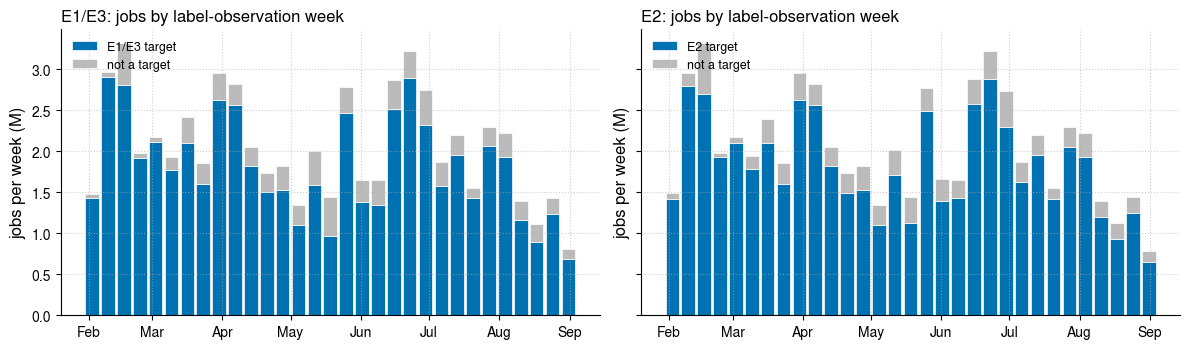

64,088,358 rows
  E1/E3  targets   56,131,253  (87.6% of rows)
  E2     targets   56,476,143  (88.1% of rows)
  E1/E3 label source: completion 54,497,587 | start + wall clock 1,629,751 | queue date 3,915


In [1]:
# Step 1 -- when each label becomes observable, and who is a prediction target.
# E1/E3 (failure, fault type) are known when the job terminates; E2 (wait time) when
# it starts executing. Targets: E1/E3 = jobs that ran and are not pilots (the harness
# mask); E2 = jobs with a measured wait.
TEST_SHARE = 0.20            # latest share of E1/E3 targets held out as the OOT test set
RANDOM_TEST_FRACTION = 0.10  # random arm's own test set, drawn from the training window
VAL_FRAC = 0.10              # validation slice inside each arm's training rows
SPLIT_SEED = 42
SAVE = False                 # step 8 writes DATA_ROOT/splits_8020.npz when True

import os
import json
import datetime as dt

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from eval.paths import DATA_ROOT
from eval.dataset import WINDOW_FLOOR
from eval.helper import terminal_time

from eval.style import apply_style

apply_style()
C_TRAIN, C_TEST, C_RTEST, C_VAL, C_PURGE = (
    "#0072B2", "#D55E00", "#009E73", "#E69F00", "#CC79A7")
C_OTHER = "#BBBBBB"
EXPS = ("E1/E3", "E2")

T = np.load(os.path.join(DATA_ROOT, "targets_and_masks.npz"))
qs, jst, comp, wall = (T[k].astype(np.float64) for k in ("qs", "jst", "comp", "wall"))
failed, hw, wait_sv = T["failed"], T["hw"], T["wait_sv"].astype(np.float64)
ran = T["ran"].astype(bool)
is_pilot = np.load(os.path.join(DATA_ROOT, "is_pilot.npy")).astype(bool)
N = len(qs)

tau, pop = {}, {}
tau["E1/E3"], _src = terminal_time(comp, job_start=jst, wall_clock=wall, qdate=qs,
                                   floor=WINDOW_FLOOR)
tau["E2"], _ = terminal_time(jst, job_start=jst, wall_clock=wall, qdate=qs,
                             floor=WINDOW_FLOOR)
pop["E1/E3"] = ran & ~is_pilot & np.isfinite(tau["E1/E3"])
pop["E2"] = np.isfinite(wait_sv) & np.isfinite(tau["E2"])

# Weekly bins over the whole window, shared by every figure below.
_lo = np.nanmin([np.nanmin(tau[e][pop[e]]) for e in EXPS])
_hi = np.nanmax([np.nanmax(tau[e][pop[e]]) for e in EXPS])
WEEK = 7 * 86400
EDGES = np.arange(np.floor(_lo / WEEK) * WEEK, _hi + WEEK, WEEK)
CENTRES = [dt.datetime.fromtimestamp(x + WEEK / 2, dt.timezone.utc) for x in EDGES[:-1]]


def weekly(t):
    return np.histogram(t, EDGES)[0]


def stacked(ax, parts, title):
    """parts: [(label, times, colour)], stacked weekly bars in that order."""
    bottom = np.zeros(len(EDGES) - 1)
    for label, t, col in parts:
        h = weekly(t)
        ax.bar(CENTRES, h / 1e6, width=6, bottom=bottom / 1e6, color=col, label=label,
               edgecolor="white", linewidth=0.5)
        bottom += h
    ax.set_title(title, loc="left")
    ax.set_ylabel("jobs per week (M)")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
    ax.legend(frameon=False, fontsize=9, loc="upper left")


def fmt_day(x):
    return dt.datetime.fromtimestamp(x, dt.timezone.utc).strftime("%Y-%m-%d %H:%M UTC")


fig, axes = plt.subplots(1, 2, figsize=(12, 3.6), sharey=True)
for ax, e in zip(axes, EXPS):
    other = np.isfinite(tau[e]) & ~pop[e]
    stacked(ax, [(f"{e} target", tau[e][pop[e]], C_TRAIN),
                 ("not a target", tau[e][other], C_OTHER)],
            f"{e}: jobs by label-observation week")
fig.tight_layout(); plt.show()

print(f"{N:,} rows")
for e in EXPS:
    print(f"  {e:6s} targets {pop[e].sum():>12,}  ({pop[e].mean() * 100:.1f}% of rows)")
print(f"  E1/E3 label source: completion {(_src[pop['E1/E3']] == 0).sum():,} | "
      f"start + wall clock {(_src[pop['E1/E3']] == 1).sum():,} | "
      f"queue date {(_src[pop['E1/E3']] == 2).sum():,}")


#### Step 2 -- the cutoff
The UTC midnight closest to the point where 80% of E1/E3 labels have been observed; one date for every experiment.

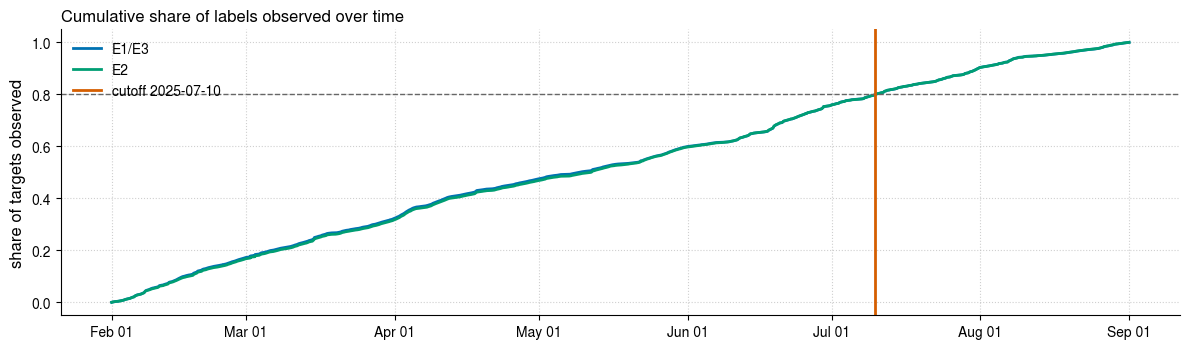

80% point of E1/E3 labels: 2025-07-10 04:44 UTC
cutoff (nearest midnight): 2025-07-10 00:00 UTC
  E1/E3  before cutoff 79.82% | after 20.18%
  E2     before cutoff 79.86% | after 20.14%


In [4]:
# Step 2 -- the cutoff. One date for every experiment: the UTC midnight closest to
# the point where (1 - TEST_SHARE) of E1/E3 targets have an observed label. Each
# experiment then assigns its jobs by its own label time, so E2's share differs a little.
DAY = 86400
t13 = tau["E1/E3"][pop["E1/E3"]]
q = float(np.quantile(t13, 1 - TEST_SHARE))
CUTOFF = min((np.floor(q / DAY) * DAY, np.ceil(q / DAY) * DAY),
             key=lambda c: abs((t13 < c).mean() - (1 - TEST_SHARE)))

fig, ax = plt.subplots(figsize=(12, 3.6))
for e, col in zip(EXPS, (C_TRAIN, C_RTEST)):
    t = np.sort(tau[e][pop[e]])
    step = max(1, len(t) // 4000)
    ax.plot([dt.datetime.fromtimestamp(x, dt.timezone.utc) for x in t[::step]],
            np.arange(len(t))[::step] / len(t), color=col, label=e, linewidth=2)
ax.axhline(1 - TEST_SHARE, color="0.4", linestyle="--", linewidth=1)
ax.axvline(dt.datetime.fromtimestamp(CUTOFF, dt.timezone.utc), color=C_TEST, linewidth=2,
           label=f"cutoff {fmt_day(CUTOFF)[:10]}")
ax.set_ylabel("share of targets observed")
ax.set_title("Cumulative share of labels observed over time", loc="left")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.legend(frameon=False, loc="upper left")
fig.tight_layout(); plt.show()

print(f"{(1 - TEST_SHARE):.0%} point of E1/E3 labels: {fmt_day(q)}")
print(f"cutoff (nearest midnight): {fmt_day(CUTOFF)}")
for e in EXPS:
    s = (tau[e][pop[e]] < CUTOFF).mean()
    print(f"  {e:6s} before cutoff {s:.2%} | after {1 - s:.2%}")

#### Step 3 -- train / test by label time
A job can train only if its outcome was known before the cutoff; everything still outstanding is test.

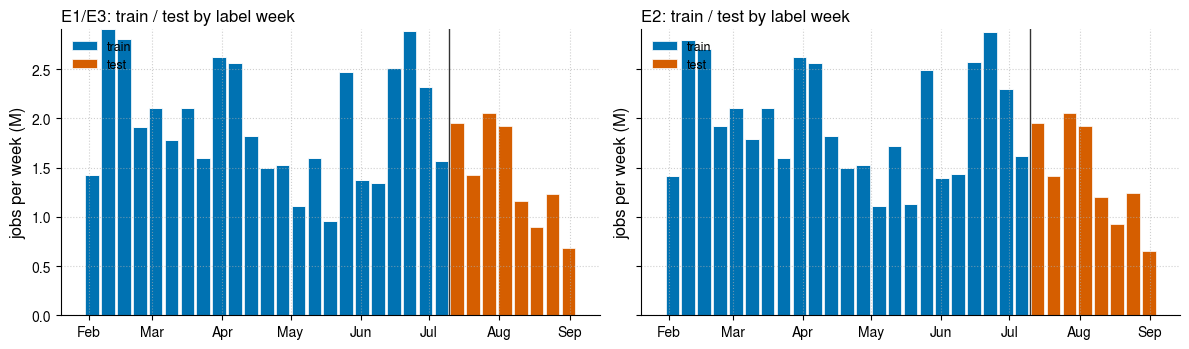

  E1/E3  train   44,803,115 | test  11,328,138 (20.2%)
  E2     train   45,100,449 | test  11,375,694 (20.1%)


In [5]:
# Step 3 -- train / test by label-observation time. A job can train only if its
# outcome was known before the cutoff; everything still outstanding is test.
train, test = {}, {}
for e in EXPS:
    train[e] = pop[e] & (tau[e] < CUTOFF)
    test[e] = pop[e] & (tau[e] >= CUTOFF)
    assert not (train[e] & test[e]).any() and ((train[e] | test[e]) == pop[e]).all()

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6), sharey=True)
for ax, e in zip(axes, EXPS):
    stacked(ax, [("train", tau[e][train[e]], C_TRAIN), ("test", tau[e][test[e]], C_TEST)],
            f"{e}: train / test by label week")
    ax.axvline(dt.datetime.fromtimestamp(CUTOFF, dt.timezone.utc), color="0.2", linewidth=1)
fig.tight_layout(); plt.show()

for e in EXPS:
    print(f"  {e:6s} train {train[e].sum():>12,} | test {test[e].sum():>11,} "
          f"({test[e].sum() / pop[e].sum():.1%})")


#### Step 4 -- purge straddlers
Test jobs queued before the cutoff are removed from the test set (they are not in training either).

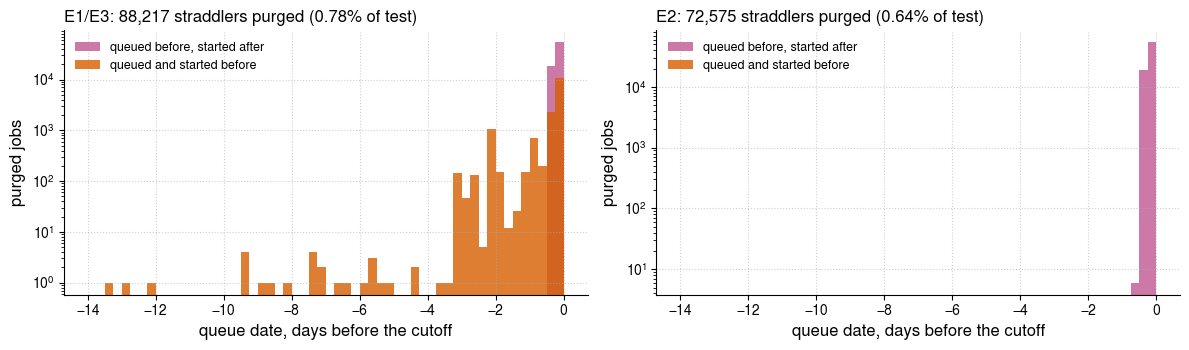

  E1/E3  test 11,328,138 -> 11,239,921 | purged 88,217 (started before cutoff 15,873, queued only 72,344) | oldest queue date 110.3 days before
  E2     test 11,375,694 -> 11,303,119 | purged 72,575 (started before cutoff 0, queued only 72,575) | oldest queue date 0.5 days before


In [6]:
# Step 4 -- purge straddlers. A test job straddles the cutoff when its life began
# before it: queued before the cutoff (and possibly already running) but observed
# after. Its prediction would have been made before the cutoff, by a model that could
# not have seen the last days of outcomes that the training set contains. Purged jobs
# leave the test set; they were never in training (their labels post-date the cutoff).
straddle, test_clean = {}, {}
for e in EXPS:
    straddle[e] = test[e] & (qs < CUTOFF)
    test_clean[e] = test[e] & ~straddle[e]

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
for ax, e in zip(axes, EXPS):
    s = straddle[e]
    started = s & np.isfinite(jst) & (jst < CUTOFF)
    bins = np.linspace(-14, 0, 57)
    ax.hist((qs[s & ~started] - CUTOFF) / DAY, bins=bins, color=C_PURGE,
            label="queued before, started after")
    ax.hist((qs[started] - CUTOFF) / DAY, bins=bins, color=C_TEST, alpha=0.8,
            label="queued and started before")
    ax.set_yscale("log")
    ax.set_xlabel("queue date, days before the cutoff")
    ax.set_ylabel("purged jobs")
    ax.set_title(f"{e}: {s.sum():,} straddlers purged ({s.sum() / test[e].sum():.2%} of test)",
                 loc="left")
    ax.legend(frameon=False, fontsize=9)
fig.tight_layout(); plt.show()

for e in EXPS:
    s = straddle[e]
    started = s & np.isfinite(jst) & (jst < CUTOFF)
    print(f"  {e:6s} test {test[e].sum():>10,} -> {test_clean[e].sum():>10,} | purged "
          f"{s.sum():,} (started before cutoff {started.sum():,}, queued only "
          f"{(s & ~started).sum():,}) | oldest queue date "
          f"{(CUTOFF - np.nanmin(qs[s])) / DAY if s.any() else 0:.1f} days before")


#### Step 5 -- the random arm's test set
A random 10% of the training window, scored only by the random arm; both arms train on the rest.

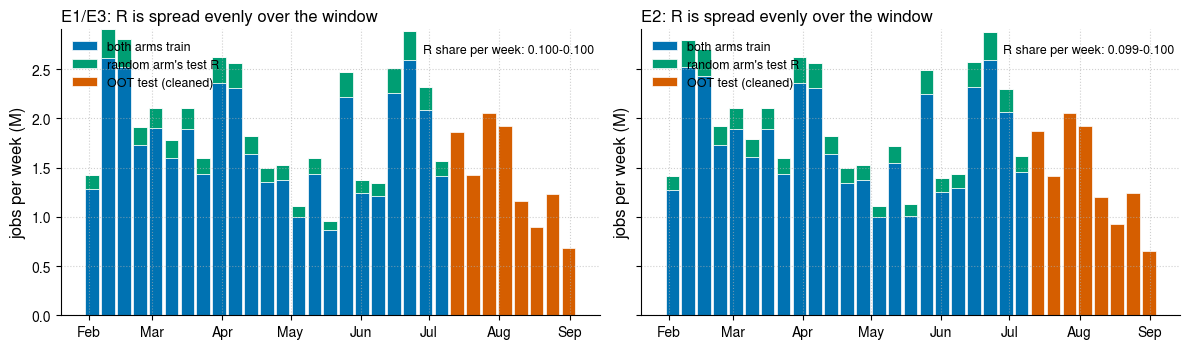

  E1/E3  window   44,803,115 -> both arms train   40,321,927 | R  4,481,188
  E2     window   45,100,449 -> both arms train   40,589,558 | R  4,510,891


In [11]:
# Step 5 -- the random arm's own test set R: a random RANDOM_TEST_FRACTION of the
# training window. Drawn once over all rows, so a job is on the same side in every
# experiment. Both arms then train on the window minus R; R is scored only by the
# random arm ("Random, Random"), the cleaned test set by both.
rng = np.random.default_rng(SPLIT_SEED)
in_R = rng.random(N) < RANDOM_TEST_FRACTION
rtest, arm_train = {}, {}
for e in EXPS:
    rtest[e] = train[e] & in_R
    arm_train[e] = train[e] & ~in_R

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6), sharey=True)
for ax, e in zip(axes, EXPS):
    stacked(ax, [("both arms train", tau[e][arm_train[e]], C_TRAIN),
                 ("random arm's test R", tau[e][rtest[e]], C_RTEST),
                 ("OOT test (cleaned)", tau[e][test_clean[e]], C_TEST)],
            f"{e}: R is spread evenly over the window")
    share = weekly(tau[e][rtest[e]]) / np.maximum(weekly(tau[e][train[e]]), 1)
    ok = weekly(tau[e][train[e]]) > 0
    ax.text(0.99, 0.95, f"R share per week: {share[ok].min():.3f}-{share[ok].max():.3f}",
            transform=ax.transAxes, ha="right", va="top", fontsize=9)
fig.tight_layout(); plt.show()

for e in EXPS:
    print(f"  {e:6s} window {train[e].sum():>12,} -> both arms train "
          f"{arm_train[e].sum():>12,} | R {rtest[e].sum():>10,}")


#### Step 6 -- validation slices
The temporal arm validates on jobs submitted on or after a date V (the midnight nearest the 90% point of submit times); every job submitted before V trains. The random arm validates on a random draw of the same number of jobs, so both arms fit and validate on equal-sized sets.

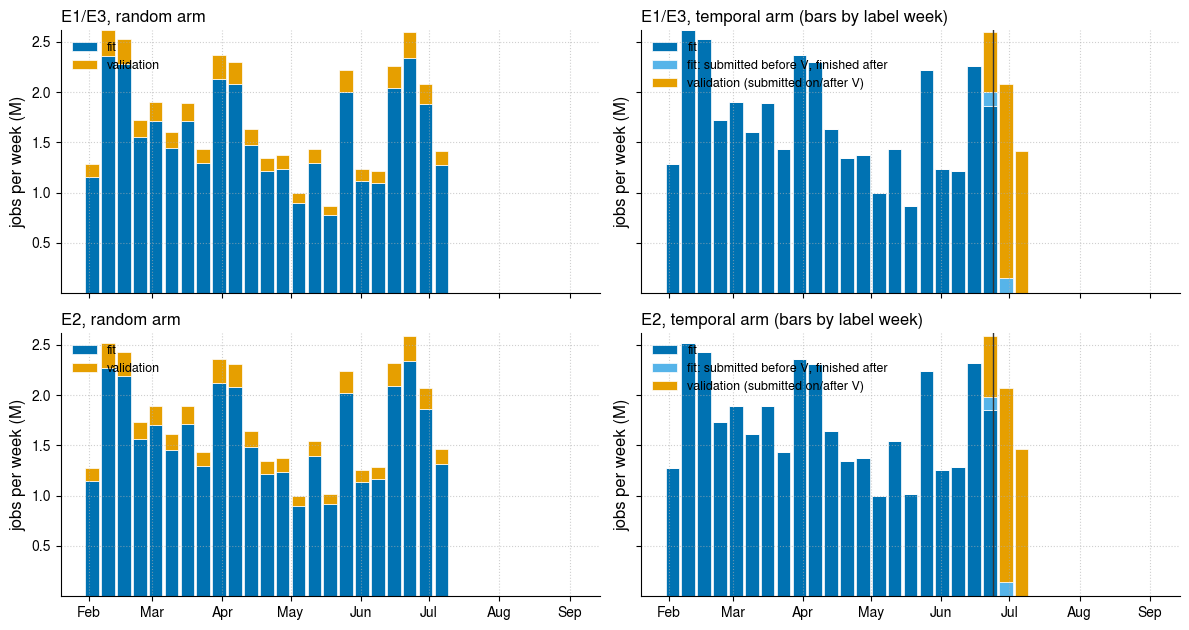

validation start V = 2025-06-24 00:00 UTC  (90% point of E1/E3 submit times: 2025-06-23 19:17 UTC)
  E1/E3  random   fit   36,379,869 | val  3,942,058 (9.8%; submitted 2025-02-01 .. 2025-07-09)
  E1/E3  temporal fit   36,379,869 | val  3,942,058 (9.8%; submitted 2025-06-24 .. 2025-07-09)
  E1/E3  temporal: 286,908 training jobs were still running at V (submitted before, finished after) -- kept in training
  E2     random   fit   36,587,590 | val  4,001,968 (9.9%; submitted 2025-02-01 .. 2025-07-09)
  E2     temporal fit   36,587,590 | val  4,001,968 (9.9%; submitted 2025-06-24 .. 2025-07-09)
  E2     temporal: 261,686 training jobs were still running at V (submitted before, finished after) -- kept in training


In [12]:
# Step 6 -- each arm's validation slice, carved from the shared training rows. The
# validation rows are not trained on; they set each model's threshold (and are where
# the arms differ).
#   Temporal arm: split by SUBMIT time at a calendar date V -- the UTC midnight closest
#   to the point where (1 - VAL_FRAC) of the E1/E3 training rows had been submitted, one
#   date for every experiment. Validation = jobs submitted on or after V. Every job
#   submitted before V trains, including jobs still running at V that finished after
#   it, so no validation job was submitted earlier than any training job.
#   Random arm: a random draw of exactly as many jobs as the temporal arm's validation
#   slice, so V sets the size for both and the two arms fit and validate on the same
#   number of jobs.

q13 = qs[arm_train["E1/E3"]]
qv = float(np.quantile(q13, 1 - VAL_FRAC))
VAL_START = min((np.floor(qv / DAY) * DAY, np.ceil(qv / DAY) * DAY),
                key=lambda c: abs((q13 < c).mean() - (1 - VAL_FRAC)))

fit, val, still_running = {}, {}, {}
for e in EXPS:
    idx = np.where(arm_train[e])[0]
    val[(e, "temporal")] = idx[qs[idx] >= VAL_START]
    fit[(e, "temporal")] = idx[qs[idx] < VAL_START]
    _pick = np.zeros(len(idx), dtype=bool)
    _pick[np.random.default_rng(SPLIT_SEED).choice(len(idx), len(val[(e, "temporal")]),
                                                   replace=False)] = True
    val[(e, "random")], fit[(e, "random")] = idx[_pick], idx[~_pick]
    assert len(val[(e, "random")]) == len(val[(e, "temporal")])
    assert len(fit[(e, "random")]) == len(fit[(e, "temporal")])
    # Submitted before V but finished after it: kept in training by design.
    still_running[e] = fit[(e, "temporal")][tau[e][fit[(e, "temporal")]] >= VAL_START]
    assert (qs[val[(e, "temporal")]] >= VAL_START).all()
    assert (qs[fit[(e, "temporal")]] < VAL_START).all()
    assert len(fit[(e, "temporal")]) + len(val[(e, "temporal")]) == len(idx)

C_RUNNING = "#56B4E9"      # lighter blue: training jobs still running at V
_v_line = dt.datetime.fromtimestamp(VAL_START, dt.timezone.utc)
fig, axes = plt.subplots(2, 2, figsize=(12, 6.4), sharex=True, sharey=True)
for r, e in enumerate(EXPS):
    stacked(axes[r, 0], [("fit", tau[e][fit[(e, "random")]], C_TRAIN),
                         ("validation", tau[e][val[(e, "random")]], C_VAL)],
            f"{e}, random arm")
    _done = np.setdiff1d(fit[(e, "temporal")], still_running[e], assume_unique=True)
    stacked(axes[r, 1], [("fit", tau[e][_done], C_TRAIN),
                         ("fit: submitted before V, finished after", tau[e][still_running[e]],
                          C_RUNNING),
                         ("validation (submitted on/after V)", tau[e][val[(e, "temporal")]],
                          C_VAL)],
            f"{e}, temporal arm (bars by label week)")
    axes[r, 1].axvline(_v_line, color="0.2", linewidth=1)
fig.tight_layout(); plt.show()

print(f"validation start V = {fmt_day(VAL_START)}  ({(1 - VAL_FRAC):.0%} point of E1/E3 "
      f"submit times: {fmt_day(qv)})")
for e in EXPS:
    for arm in ("random", "temporal"):
        v = val[(e, arm)]
        print(f"  {e:6s} {arm:8s} fit {len(fit[(e, arm)]):>12,} | val {len(v):>10,} "
              f"({len(v) / arm_train[e].sum():.1%}; submitted {fmt_day(np.nanmin(qs[v]))[:10]}"
              f" .. {fmt_day(np.nanmax(qs[v]))[:10]})")
    print(f"  {e:6s} temporal: {len(still_running[e]):,} training jobs were still running at V "
          f"(submitted before, finished after) -- kept in training")

#### Step 7 -- summary
Size, date range and label rates of every set.

,exp,set,jobs,share of targets,label from,label to,failure rate,hardware share of failures,median wait (min)
0,E1/E3,random arm: fit,"36,379,869",64.8%,2025-02-01,2025-07-09,0.146,0.055,
1,E1/E3,random arm: validation,"3,942,058",7.0%,2025-02-01,2025-07-09,0.146,0.055,
2,E1/E3,temporal arm: fit,"36,379,869",64.8%,2025-02-01,2025-07-09,0.142,0.050,
3,E1/E3,temporal arm: validation,"3,942,058",7.0%,2025-06-24,2025-07-09,0.181,0.094,
4,E1/E3,random arm: test R,"4,481,188",8.0%,2025-02-01,2025-07-09,0.146,0.056,
5,E1/E3,OOT test (both arms),"11,239,921",20.0%,2025-07-10,2025-08-31,0.133,0.109,
6,E1/E3,purged straddlers,"88,217",0.2%,2025-07-10,2025-08-15,0.017,0.285,
7,E2,random arm: fit,"36,587,590",64.8%,2025-02-01,2025-07-09,,,23.1
8,E2,random arm: validation,"4,001,968",7.1%,2025-02-01,2025-07-09,,,23.1
9,E2,temporal arm: fit,"36,587,590",64.8%,2025-02-01,2025-06-30,,,21.8


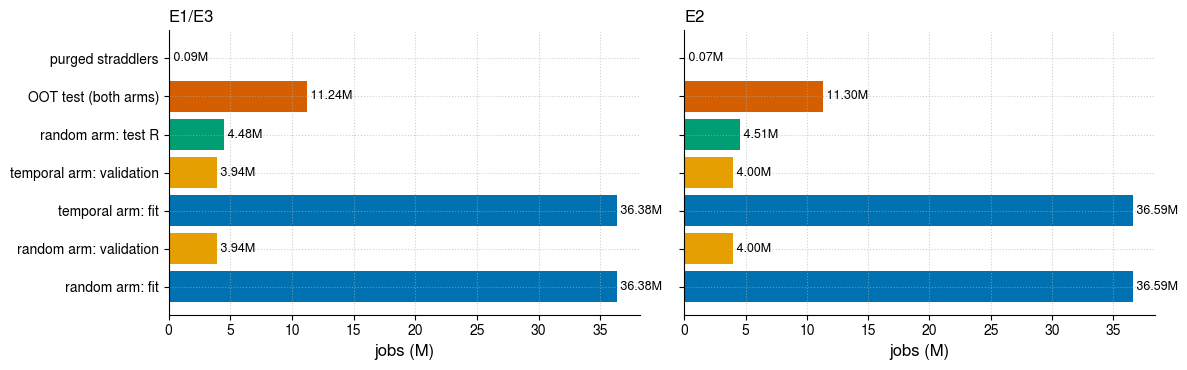

In [13]:
# Step 7 -- summary of every set, per experiment. Positive rates are what each
# metric's baseline depends on: failure rate (E1), hardware share of failures (E3),
# median wait (E2).
rows = []
for e in EXPS:
    sets = [("random arm: fit", fit[(e, "random")]), ("random arm: validation", val[(e, "random")]),
            ("temporal arm: fit", fit[(e, "temporal")]),
            ("temporal arm: validation", val[(e, "temporal")]),
            ("random arm: test R", np.where(rtest[e])[0]),
            ("OOT test (both arms)", np.where(test_clean[e])[0]),
            ("purged straddlers", np.where(straddle[e])[0])]
    for name, i in sets:
        rec = {"exp": e, "set": name, "jobs": len(i),
               "share of targets": len(i) / pop[e].sum(),
               "label from": fmt_day(np.nanmin(tau[e][i]))[:10] if len(i) else "",
               "label to": fmt_day(np.nanmax(tau[e][i]))[:10] if len(i) else ""}
        if e == "E1/E3":
            f = failed[i] == 1
            rec["failure rate"] = f.mean() if len(i) else np.nan
            rec["hardware share of failures"] = (hw[i][f] == 1).mean() if f.any() else np.nan
        else:
            rec["median wait (min)"] = np.nanmedian(wait_sv[i]) / 60 if len(i) else np.nan
        rows.append(rec)
summary = pd.DataFrame(rows)
display(summary.style.format({"jobs": "{:,}", "share of targets": "{:.1%}",
                              "failure rate": "{:.3f}", "hardware share of failures": "{:.3f}",
                              "median wait (min)": "{:.1f}"}, na_rep=""))

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharey=True)
colours = [C_TRAIN, C_VAL, C_TRAIN, C_VAL, C_RTEST, C_TEST, C_PURGE]
for ax, e in zip(axes, EXPS):
    s = summary[summary.exp == e]
    ax.barh(s["set"], s["jobs"] / 1e6, color=colours)
    for yv, n in enumerate(s["jobs"]):
        ax.text(n / 1e6, yv, f" {n / 1e6:.2f}M", va="center", fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel("jobs (M)")
    ax.set_title(e, loc="left")
fig.tight_layout(); plt.show()


#### Step 8 -- save
Writes `splits_8020.npz`

In [15]:
payload = {}
for e, key in (("E1/E3", "e1e3"), ("E2", "e2")):
    payload[f"{key}__train"] = np.where(arm_train[e])[0]
    payload[f"{key}__random_test"] = np.where(rtest[e])[0]
    payload[f"{key}__oot_test"] = np.where(test_clean[e])[0]
    payload[f"{key}__purged"] = np.where(straddle[e])[0]
    for arm in ("random", "temporal"):
        payload[f"{key}__{arm}__fit"] = fit[(e, arm)]
        payload[f"{key}__{arm}__val"] = val[(e, arm)]
out = os.path.join(DATA_ROOT, "splits_8020.npz")
np.savez_compressed(out, cutoff=np.asarray(CUTOFF), test_share=np.asarray(TEST_SHARE),
                    **payload)
print(f"wrote {out}: {', '.join(sorted(payload))}")

wrote /media/data/allison/fife/splits_8020.npz: e1e3__oot_test, e1e3__purged, e1e3__random__fit, e1e3__random__val, e1e3__random_test, e1e3__temporal__fit, e1e3__temporal__val, e1e3__train, e2__oot_test, e2__purged, e2__random__fit, e2__random__val, e2__random_test, e2__temporal__fit, e2__temporal__val, e2__train
